# IMDB MOVIE RATING ANALYSIS USING PANDAS

# Read the dataset

In [1]:
import pandas as pd

In [2]:
movies = pd.read_csv(r'C:\Users\nithi\Downloads\archive\movie.csv')
print(type(movies))
movies.head(10)

<class 'pandas.core.frame.DataFrame'>


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [3]:
movies.shape

(27278, 3)

In [4]:
ratings = pd.read_csv(r'C:\Users\nithi\Downloads\archive\rating.csv')
print(type(ratings))
ratings.head(10)

<class 'pandas.core.frame.DataFrame'>


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40
5,1,112,3.5,2004-09-10 03:09:00
6,1,151,4.0,2004-09-10 03:08:54
7,1,223,4.0,2005-04-02 23:46:13
8,1,253,4.0,2005-04-02 23:35:40
9,1,260,4.0,2005-04-02 23:33:46


In [5]:
ratings.shape

(20000263, 4)

In [6]:
tags = pd.read_csv(r'C:\Users\nithi\Downloads\archive\tag.csv')
print(type(tags))
tags.head(10)

<class 'pandas.core.frame.DataFrame'>


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18
5,65,668,bollywood,2013-05-10 01:37:56
6,65,898,screwball comedy,2013-05-10 01:42:40
7,65,1248,noir thriller,2013-05-10 01:39:43
8,65,1391,mars,2013-05-10 01:40:55
9,65,1617,neo-noir,2013-05-10 01:43:37


In [7]:
tags.shape

(465564, 4)

In [8]:
print(len(movies))
print(len(ratings))
print(len(tags))

27278
20000263
465564


# For current analysis, we remove timestamp

In [9]:
del ratings['timestamp']
del tags['timestamp']

In [10]:
ratings.head(10)

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5
5,1,112,3.5
6,1,151,4.0
7,1,223,4.0
8,1,253,4.0
9,1,260,4.0


In [11]:
tags.head(10)

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero
5,65,668,bollywood
6,65,898,screwball comedy
7,65,1248,noir thriller
8,65,1391,mars
9,65,1617,neo-noir


In [12]:
ratings.columns

Index(['userId', 'movieId', 'rating'], dtype='object')

In [13]:
len(ratings.columns)

3

In [14]:
ratings.head(2)

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5


# Data Structure

Series

In [15]:
tags

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero
...,...,...,...
465559,138446,55999,dragged
465560,138446,55999,Jason Bateman
465561,138446,55999,quirky
465562,138446,55999,sad


In [16]:
tags.head(5)

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [17]:
tags.iloc[0:4] 

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller


In [18]:
row_0 = tags.iloc[0]
type(row_0)

pandas.core.series.Series

In [19]:
row_0

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object

In [20]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='object')

In [21]:
row_0.name

0

In [22]:
row_0 = row_0.rename('first Row')
row_0.name

'first Row'

DataFrames

In [23]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [24]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [25]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [26]:
tags.iloc[0]

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object

In [27]:
tags.iloc[[0,11,500]]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


# Descriptive Statistics

In [28]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [29]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [30]:
ratings['rating'].mean()

3.5255285642993797

In [31]:
ratings.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [32]:
ratings['rating'].min()

0.5

In [33]:
ratings['rating'].max()

5.0

In [34]:
ratings['rating'].std()

1.051988919275684

In [35]:
ratings['rating'].count()

20000263

In [36]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [37]:
ratings['rating'].median()

3.5

In [38]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [39]:
filter1 = ratings['rating']>10
print(filter1)
filter1.any()

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool


False

In [40]:
filter1.all()

False

In [41]:
filter2 = ratings['rating']>0
filter2.all()

True

# Data Cleaning: Handling missing data

In [42]:
movies.shape

(27278, 3)

In [43]:
movies.isnull().any().any()  #No null values

False

In [44]:
ratings.shape

(20000263, 3)

In [45]:
ratings.isnull().any().any()  #No null values

False

In [46]:
tags.shape

(465564, 3)

In [47]:
tags.isnull().any().any() #we have some tags which are NULL value

True

In [48]:
tags= tags.dropna()

In [49]:
tags.isnull().any().any()

False

In [50]:
tags.shape  #16 tags are dropped

(465548, 3)

DATA VISUALISATION

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

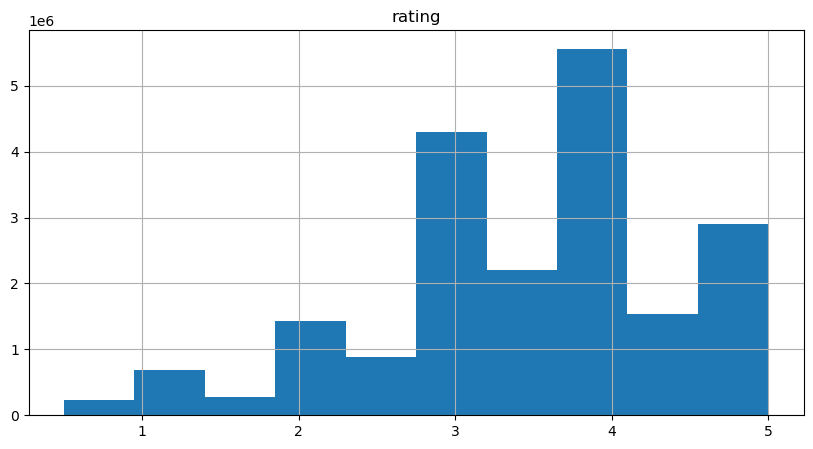

In [51]:
%matplotlib inline

ratings.hist(column='rating', figsize=(10,5))

<Axes: >

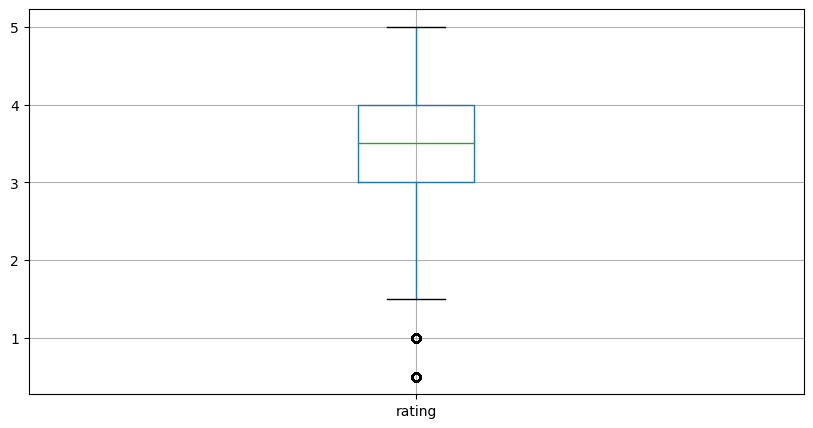

In [52]:
ratings.boxplot(column='rating', figsize=(10,5))

Slicing Out Columns

In [53]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [54]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [55]:
ratings[0:10]

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5
5,1,112,3.5
6,1,151,4.0
7,1,223,4.0
8,1,253,4.0
9,1,260,4.0


In [56]:
ratings[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [57]:
tag_counts = tags['tag'].value_counts()
tag_counts[-10:]

missing child                    1
Ron Moore                        1
Citizen Kane                     1
mullet                           1
biker gang                       1
Paul Adelstein                   1
the wig                          1
killer fish                      1
genetically modified monsters    1
topless scene                    1
Name: tag, dtype: int64

<Axes: >

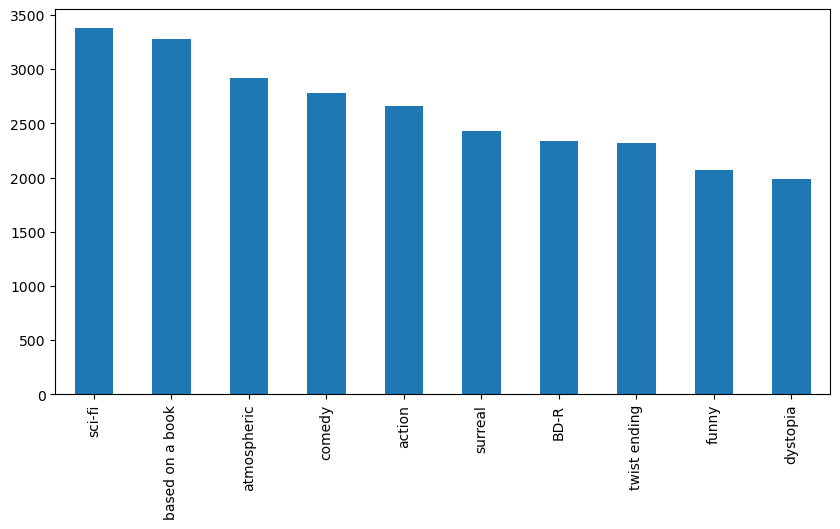

In [58]:
tag_counts[:10].plot(kind='bar', figsize=(10,5))

kind : str
    The kind of plot to produce:
        
    -'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'density' : same as 'kde'
    - 'area' : area plot
    - 'pie' : pie plot
    - 'scatter' : scatter plot (DataFrame only)
    - 'hexbin' : hexbin plot (DataFrame only)

# 45 to 76